# 06 五轴与机床轴

五轴加工在每个刀位点上不只要给刀尖位置 $\mathbf{p}$，还要给单位刀轴 $\hat{\mathbf{o}}$；进给规划在工件坐标系里做，机床执行的是 5 根轴的运动，两者由机床运动学连接。本节要回答：

1. 五轴刀位由什么组成？刀轴怎么插值？
2. 机床的 A、C 轴怎样由刀轴算出？哪里会奇异？
3. 刀尖进给满足限制时，各轴一定满足吗？
4. 超限时怎么办？

前置知识：[01](01_曲线与导数栈.ipynb) 曲线与导数栈（`calculus.compose`、`unit_derivatives`），[03](03_样条拟合.ipynb) 样条拟合，[04](04_S曲线与前瞻.ipynb) S 曲线与前瞻，[05](05_拐角光顺.ipynb) 拐角光顺。

In [1]:
import os.path as osp
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root_path = Path(osp.abspath("")).parents[0]
sys.path.append(str(root_path))

%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np

import cnc5x as cx
from cnc5x import plotting

plotting.use_style()

## 1. 五轴刀位数据

三轴 G01 一行只有一个点；五轴一行有六个数：刀尖位置 $\mathbf{p}$（mm）与**单位刀轴** $\hat{\mathbf{o}}$。全库的约定（CLAUDE.md 第 3.8 条）是**刀轴由刀尖指向刀柄**，内部单位统一为 mm、s、rad。数据本身仍然是逐点离散的刀位，连续化是下一节的事。

内置数据 `horseshoe_planar_sweep`（25 个刀位，来自 HUST iRobotCNC 的 MATLAB 工程的默认演示刀路）：一条平面 S 形曲线，刀轴倾角在 10° 到 42° 之间连续变化。

In [3]:
TS = 0.001  # 插补周期，全节共用
data = cx.datasets.load_dataset("horseshoe_planar_sweep")
print(f"{data.name}：{len(data.points)} 个刀位")
print(f"刀尖坐标范围：X [{data.points[:, 0].min():.1f}, {data.points[:, 0].max():.1f}] mm")
print(f"刀轴 z 分量范围：[{data.axes[:, 2].min():.3f}, {data.axes[:, 2].max():.3f}]（始终朝上）")
data.info["description"]

horseshoe_planar_sweep：25 个刀位
刀尖坐标范围：X [-49.4, 117.9] mm
刀轴 z 分量范围：[0.749, 0.984]（始终朝上）


'25 点，平面马蹄形/S 形曲线，刀轴 10°–42° 连续变倾（MATLAB 工程的默认演示刀路）'

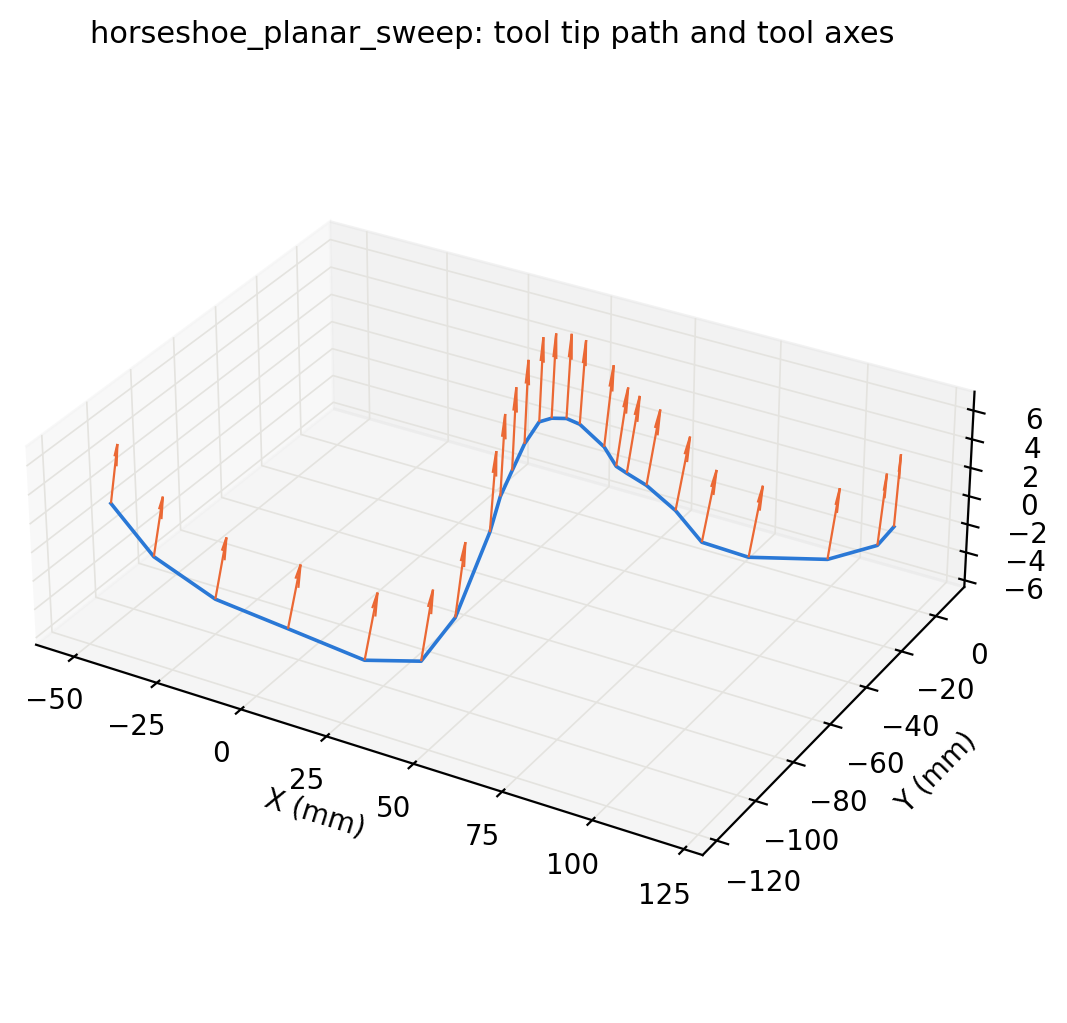

In [4]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
plotting.plot_tool_axes(ax, data.points, data.axes, every=1, length=6)
ax.set_box_aspect((4, 3, 1.2))  # 不然 z 方向被拉得过长
ax.set_title("horseshoe_planar_sweep: tool tip path and tool axes")
plt.show()

**要点**：五轴刀位 = 刀尖 $\mathbf{p}$（mm）+ 单位刀轴 $\hat{\mathbf{o}}$（由刀尖指向刀柄）；刀轴的"位移"是单位球面上的弧长，单位是 rad，和毫米不是一回事。

## 2. 刀轴插值

两个刀轴之间的最短过渡是**大圆弧**（slerp，球面线性插值）：设 $\theta=\angle(\hat{\mathbf{o}}_0,\hat{\mathbf{o}}_1)$，$\hat{\mathbf{t}}_0$ 是 $\hat{\mathbf{o}}_0$ 处指向 $\hat{\mathbf{o}}_1$ 的球面切向，

$$
\hat{\mathbf{o}}(u)=\cos(u\theta)\,\hat{\mathbf{o}}_0+\sin(u\theta)\,\hat{\mathbf{t}}_0,\qquad
\hat{\mathbf{o}}^{(k)}(u)=\theta^{k}\!\left[\cos\!\big(u\theta+\tfrac{k\pi}{2}\big)\,\hat{\mathbf{o}}_0+\sin\!\big(u\theta+\tfrac{k\pi}{2}\big)\,\hat{\mathbf{t}}_0\right].
$$

$|\hat{\mathbf{o}}|\equiv1$ 是精确的，$|\hat{\mathbf{o}}'|\equiv\theta$ 恒定，所以角速度恒定、弧长有解析式 $s=\theta u$。这正是 G01 五轴段（`PolylinePath.g01`）里刀轴的走法。

In [5]:
o0 = cx.unit([0.2, 0.1, 1.0])
o1 = cx.unit([0.0, 0.6, 1.0])
arc = cx.GreatCircle(o0, o1)
d = arc.derivatives(np.linspace(0, 1, 9))
print(f"夹角 θ = {arc.theta:.4f} rad = {np.degrees(arc.theta):.2f}°，弧长 = {arc.length:.4f} rad（两者相等）")
print(f"|o| − 1 的最大偏差：{np.abs(np.linalg.norm(d[0], axis=-1) - 1).max():.1e}")
norm1 = np.linalg.norm(d[1], axis=-1)
print(f"|do/du| 逐点值：{np.array2string(norm1, precision=4)}")

夹角 θ = 0.4799 rad = 27.50°，弧长 = 0.4799 rad（两者相等）
|o| − 1 的最大偏差：0.0e+00
|do/du| 逐点值：[0.4799 0.4799 0.4799 0.4799 0.4799 0.4799 0.4799 0.4799 0.4799]


In [6]:
# 独立参考：解析弧长 = 两向量夹角
assert np.allclose(np.linalg.norm(d[0], axis=-1), 1.0, atol=1e-14)
assert np.abs(arc.length - np.arccos(np.dot(o0, o1))) < 1e-14
assert np.allclose(np.linalg.norm(d[1], axis=-1), arc.theta, atol=1e-14)
print("全部通过：单位长度、恒定角速度 θ、解析弧长 = 夹角")

全部通过：单位长度、恒定角速度 θ、解析弧长 = 夹角


一段刀轴变化很多（采样点也密）时，G01 的逐段大圆太零碎，要像刀尖一样拟合一条样条。做法（`pose_spline`）：先对单位刀轴插值一条三维 B 样条 $\mathbf{r}(u)$，再**单位化** $\hat{\mathbf{o}}=\mathbf{r}/|\mathbf{r}|$（`UnitDirection`）。单位化的各阶导数由 `calculus.unit_derivatives` 从 $\mathbf{r}$ 的导数栈逐阶解出：

$$
\hat{\mathbf{o}}'=\frac{\mathbf{r}'-\rho'\hat{\mathbf{o}}}{\rho},\qquad
\hat{\mathbf{o}}''=\frac{\mathbf{r}''-\rho''\hat{\mathbf{o}}-2\rho'\hat{\mathbf{o}}'}{\rho},\qquad \rho=\lVert\mathbf{r}\rVert .
$$

注意 $\hat{\mathbf{o}}'$ 里砍掉了 $\mathbf{r}'$ 沿 $\hat{\mathbf{o}}$ 的分量：单位向量只能沿球面切向变。

In [7]:
# 参考：直接用投影公式手算 o'，与库函数对照
r = np.array([[3.0, 4.0, 12.0], [1.0, -2.0, 0.5], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
o = cx.calculus.unit_derivatives(r)
rho = np.linalg.norm(r[0])
rho1 = np.dot(r[0], r[1]) / rho
o1_hand = (r[1] - rho1 * o[0]) / rho
print(f"手算与库函数的差：{np.abs(o1_hand - o[1]).max():.1e}")
assert np.abs(o1_hand - o[1]).max() < 1e-14
assert np.abs(np.linalg.norm(o[0]) - 1) < 1e-14  # 仍为单位向量
assert np.dot(o[0], o[1]) < 1e-14  # 单位向量的导数与自己垂直
print("o·o′ = 0 也成立（单位向量只沿切向变化）")

手算与库函数的差：0.0e+00
o·o′ = 0 也成立（单位向量只沿切向变化）


刀尖样条和刀轴样条共用一组参数 $u$（默认取刀尖的累积弦长）。但刀轴转动的快慢未必和刀尖前进的多少同步：刀尖走得稀的地方刀轴可能转得很密。于是有第二种写法（Yuen et al. 2013）：让刀轴按**自己转过的角度**参数化（`angle_parameters`），拟合 $\hat{\mathbf{o}}(w)$，再用一条严格递增的 $C^2$ 映射 $w=g(u)$ 同步回刀尖参数（`monotone_interpolate`，Fritsch & Butland 的调和平均斜率保证单调——普通三次样条插出来可能倒转）。

In [8]:
u_nodes = cx.chord_parameters(data.points)
w_nodes = cx.angle_parameters(data.axes)
pose_plain = cx.pose_spline(data.points, data.axes)  # 刀轴与刀尖共用弦长参数
pose_sync = cx.pose_spline(data.points, data.axes, orientation_parameters=w_nodes)
print(f"两条刀位曲线的刀尖弧长：{pose_plain.length:.2f} mm（同步不改变刀尖）")
total_angle = cx.geometry.angle_between(data.axes[:-1], data.axes[1:]).sum()
print(f"相邻刀轴转角之和：{total_angle:.3f} rad，平均每 mm 转角 {total_angle / pose_plain.length:.5f} rad/mm")

两条刀位曲线的刀尖弧长：344.73 mm（同步不改变刀尖）
相邻刀轴转角之和：1.967 rad，平均每 mm 转角 0.00571 rad/mm


In [9]:
# 对比两种参数化下刀轴对刀尖弧长的角速度 |do/ds|（rad/mm）
s = np.linspace(0, pose_plain.length, 4001)
d_plain = pose_plain.derivatives_by_length(pose_plain.u_at_length(s))
d_sync = pose_sync.derivatives_by_length(pose_sync.u_at_length(s))
omega_plain = np.linalg.norm(d_plain[1, :, 3:], axis=-1)
omega_sync = np.linalg.norm(d_sync[1, :, 3:], axis=-1)
print(f"共用弦长参数：max {omega_plain.max():.5f}，min {omega_plain.min():.5f} rad/mm")
print(f"按转角同步  ：max {omega_sync.max():.5f}，min {omega_sync.min():.5f} rad/mm")
print(f"单位化后 |o|−1 的最大偏差：{np.abs(np.linalg.norm(d_sync[0, :, 3:], axis=-1) - 1).max():.1e}")

共用弦长参数：max 0.00663，min 0.00475 rad/mm
按转角同步  ：max 0.00675，min 0.00476 rad/mm
单位化后 |o|−1 的最大偏差：2.2e-16


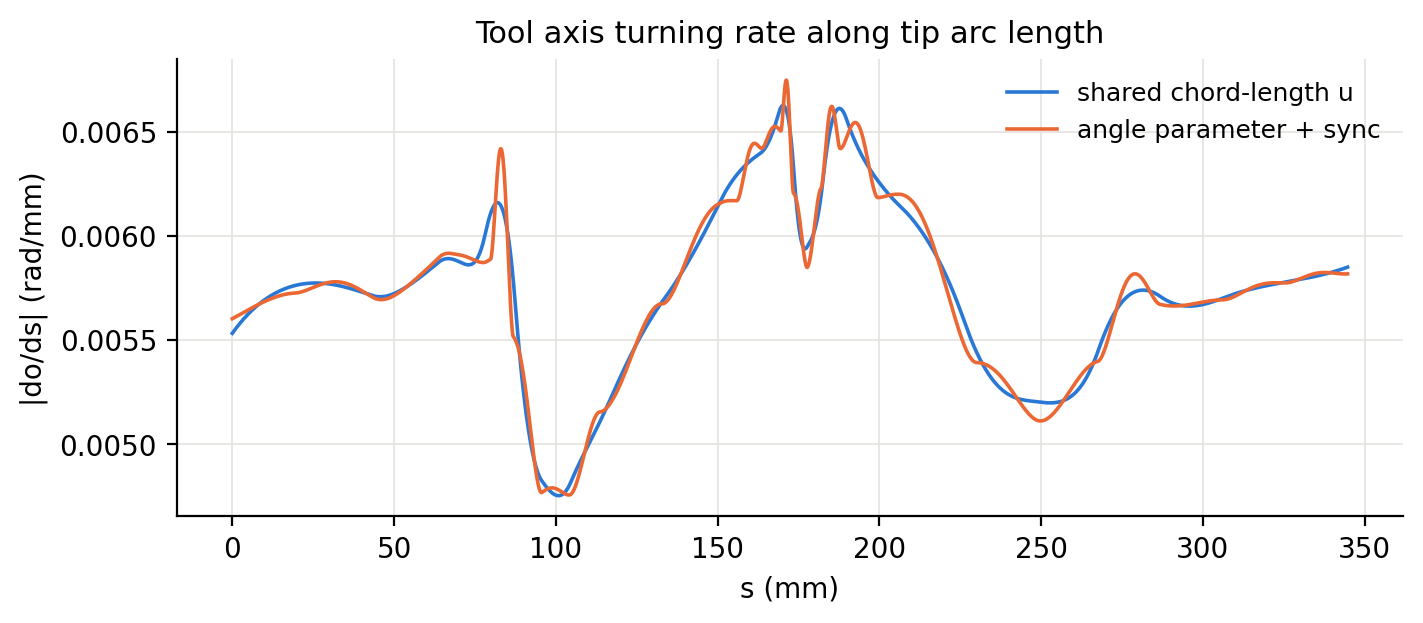

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(s, omega_plain, color=plotting.COLORS[0], label="shared chord-length u")
ax.plot(s, omega_sync, color=plotting.COLORS[1], label="angle parameter + sync")
ax.set_xlabel("s (mm)")
ax.set_ylabel("|do/ds| (rad/mm)")
ax.set_title("Tool axis turning rate along tip arc length")
ax.legend()
plt.show()

在这个数据上两条曲线几乎贴在一起（差异不到 2%）：这条刀路的刀轴转得均匀、刀尖点也排得匀，两种参数化本来就近似等价。

同步写法的价值在刀轴转动与刀尖点分布严重不匹配的数据上。`line_end_snap_sweep90` 是一条直线上的 39 个刀位：前 19 段每段 0.91 mm，刀轴每段只转 0.23°（倾角从 8.1° 缓变到 9.7°）；后 19 段每段只有 0.046 mm，刀轴每段却转 4.25°，不到 0.9 mm 内倾角从 9.7° 转到 90°。

共用刀尖弦长参数时，刀轴样条在急转段的参数间隔极短、在缓变段极长，插值样条在两段交界处会过冲。下面画倾角 $\arccos o_z$ 沿刀尖弧长的变化，灰点是原始刀位：

shared chord-length u   ：样条倾角最小 3.11°（数据最小 8.13°）
angle parameter + sync  ：样条倾角最小 8.13°（数据最小 8.13°）


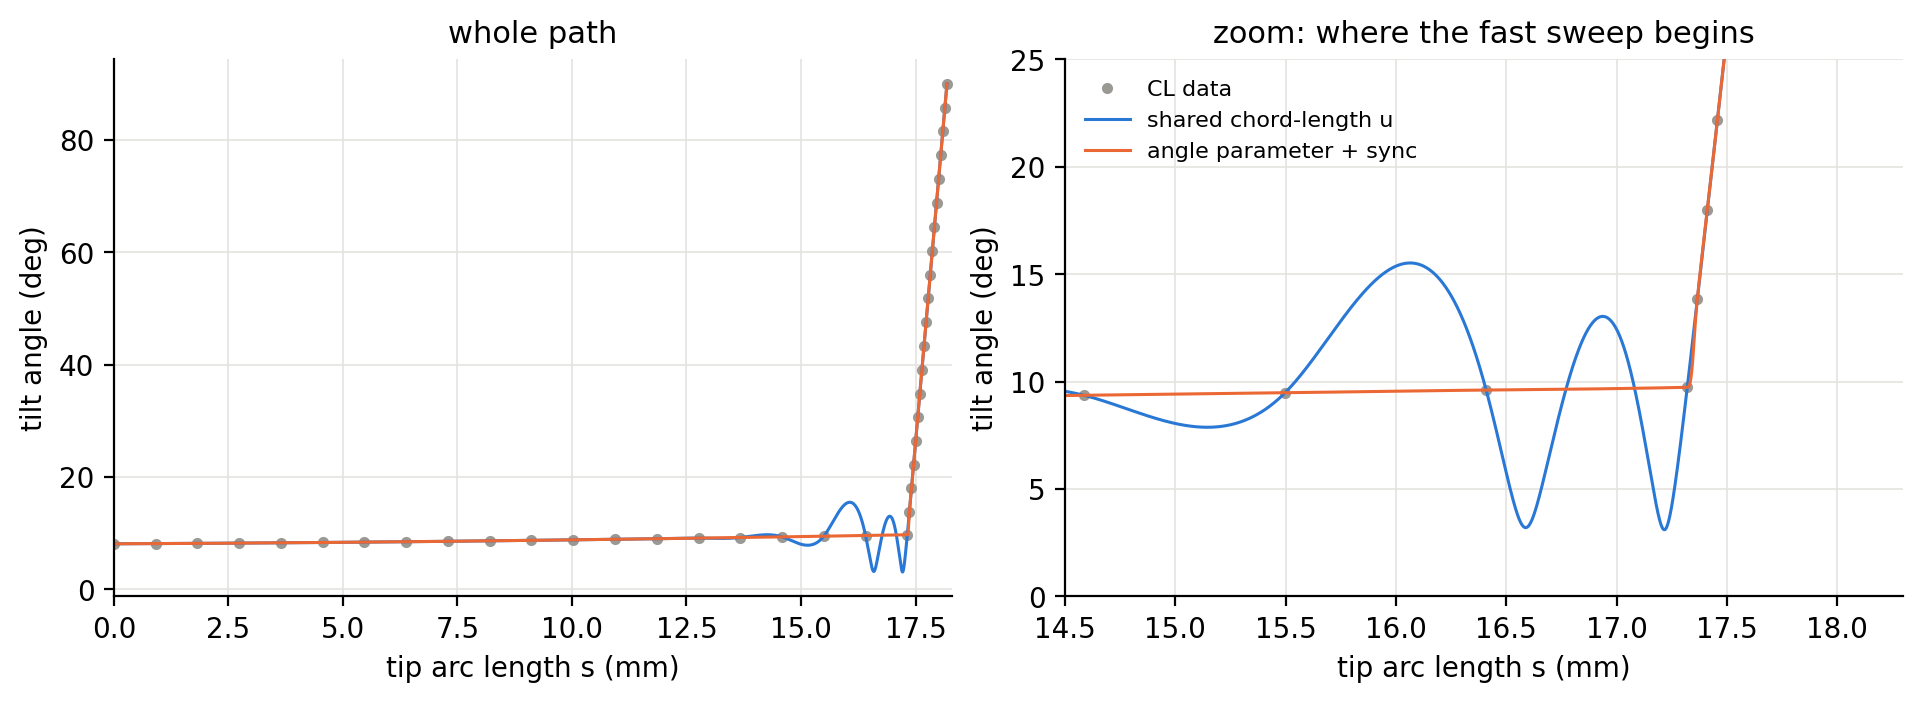

In [11]:
snap = cx.datasets.load_dataset("line_end_snap_sweep90")
snap_s = cx.chord_parameters(snap.points) * np.linalg.norm(snap.points[-1] - snap.points[0])  # 刀位点的刀尖弧长（直线）
snap_tilt = np.degrees(np.arccos(snap.axes[:, 2]))
snap_poses = {
    "shared chord-length u": cx.pose_spline(snap.points, snap.axes),
    "angle parameter + sync": cx.pose_spline(
        snap.points, snap.axes, orientation_parameters=cx.angle_parameters(snap.axes)
    ),
}
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for ax, (lo, hi) in zip(axes, ((0.0, 18.3), (14.5, 18.3))):
    ax.plot(snap_s, snap_tilt, "o", ms=3, color=plotting.GRAY, label="CL data")
    for color, (label, pose) in zip(plotting.COLORS, snap_poses.items()):
        s_fine = np.linspace(0, pose.length, 20001)
        o_fine = pose.derivatives_by_length(pose.u_at_length(s_fine))[0][:, 3:]
        ax.plot(s_fine, np.degrees(np.arccos(o_fine[:, 2])), color=color, lw=1.1, label=label)
        if lo == 0.0:
            tilt_min = np.degrees(np.arccos(o_fine[:, 2].max()))
            print(f"{label:24s}：样条倾角最小 {tilt_min:.2f}°（数据最小 {snap_tilt.min():.2f}°）")
    ax.set(xlim=(lo, hi), xlabel="tip arc length s (mm)", ylabel="tilt angle (deg)")
axes[0].set_title("whole path")
axes[1].set(ylim=(0, 25), title="zoom: where the fast sweep begins")
axes[1].legend(fontsize=8, loc="upper left")
plt.show()

In [12]:
# 检查：同步版的倾角不越出数据的范围，共用弦长版在交界处下冲到数据最小值以下
pose = snap_poses["angle parameter + sync"]
tilt_sync = np.degrees(
    np.arccos(pose.derivatives_by_length(pose.u_at_length(np.linspace(0, pose.length, 20001)))[0][:, 5])
)
assert tilt_sync.min() > snap_tilt.min() - 1e-6
print(f"同步版倾角范围 [{tilt_sync.min():.3f}°, {tilt_sync.max():.3f}°]")
print(f"数据倾角范围   [{snap_tilt.min():.3f}°, {snap_tilt.max():.3f}°]")

同步版倾角范围 [8.130°, 90.000°]
数据倾角范围   [8.130°, 90.000°]


共用弦长参数的样条在急转开始前的最后三段里来回振荡：倾角先冲到约 15.5°，又两次掉到 3.1°，比任何一个原始刀位都小 5° 左右。刀轴在那里来回摆了两次，才急转上去；这些摆动完全是插值造出来的，数据里没有。按转角参数化后，刀轴样条的参数间隔与刀轴自己转过的角度成比例（相当于刀轴自己的弦长参数化），过冲消失；单调映射 $w=g(u)$ 只改变"什么时候转到哪"，不会让刀轴倒回去。

**要点**：两刀轴之间走大圆，一串刀轴拟合样条后单位化；参数可以共用，也可以让刀轴按自己的转角参数化再单调同步。刀轴转动与刀尖点分布不匹配时，共用参数会让刀轴过冲。$|\mathrm{d}\hat{\mathbf{o}}/\mathrm{d}s|$ 是刀轴的角速度（rad/mm），是后面各轴负载的源头。

## 3. 双转台运动学

机床坐标是 5 根轴 $q=[X,Y,Z,A,C]$。双转台机床（table-tilting）的约定（CLAUDE.md 第 3.9 条，主动旋转，工件坐标 → 机床坐标）：

$$
\mathbf{R}_{AC}=\mathbf{R}_x(A)\,\mathbf{R}_z(C),\qquad
[X,Y,Z]^{T}=\mathbf{R}\,\mathbf{p}+\mathbf{b},\qquad
\hat{\mathbf{o}}=\mathbf{R}^{T}\hat{\mathbf{e}}_z .
$$

展开：$\hat{\mathbf{o}}=(\sin A\sin C,\ \sin A\cos C,\ \cos A)$。**逆解**由 $\hat{\mathbf{o}}$ 反推：倾角 $A=\pm\arccos o_z$（$\pm$ 两个分支），$C=\arg w$，其中 AC 机床取复数 $w=o_y+\mathrm{i}\,o_x$。正负 $A$ 分支的 $C$ 相差 $\pi$，是同一个刀位的两种机床姿态。

In [13]:
machine = cx.TableTilting("AC")
p_demo = data.points[[0, 12, 24]]
o_demo = data.axes[[0, 12, 24]]
q_demo = machine.inverse(p_demo, o_demo)
print(f"轴名：{machine.axis_names}")
print("A (rad) =", np.round(q_demo[:, 3], 4), " C (rad) =", np.round(q_demo[:, 4], 4))

轴名：('X', 'Y', 'Z', 'A', 'C')
A (rad) = [0.6868 0.2103 0.7184]  C (rad) = [-0.17    0.4823  1.9179]


In [14]:
# 往返检查：逆解 → 正解应回到原刀位
p_back, o_back = machine.forward(q_demo)
print(f"位置往返误差：{np.abs(p_back - p_demo).max():.1e} mm")
print(f"刀轴往返误差：{np.abs(o_back - o_demo).max():.1e}")
q_neg = machine.inverse(p_demo, o_demo, branch=-1)
p_back2, o_back2 = machine.forward(q_neg)
print(f"branch=-1 时：A = {np.round(q_neg[:, 3], 4)}，往返误差 {np.abs(o_back2 - o_demo).max():.1e}")
assert np.abs(o_back - o_demo).max() < 1e-12 and np.abs(o_back2 - o_demo).max() < 1e-12
print("两个分支都能正解回原刀位")

位置往返误差：1.4e-14 mm
刀轴往返误差：1.1e-16
branch=-1 时：A = [-0.6868 -0.2103 -0.7184]，往返误差 2.1e-16
两个分支都能正解回原刀位


In [15]:
# C 角 = arg(w)：白盒写一遍，与逆解对照
w = o_demo[:, 1] + 1j * o_demo[:, 0]
c_hand = np.angle(w)
print(f"手算 C 与逆解的差：{np.abs(c_hand - q_demo[:, 4]).max():.1e}")
assert np.abs(c_hand - q_demo[:, 4]).max() < 1e-14

手算 C 与逆解的差：0.0e+00


In [16]:
# 沿整条样条逐点逆解，C 展开成连续值（inverse_path），主值 ±π 的跳变被接起来
s_mid = np.linspace(0, pose_plain.length, 800)
d_mid = pose_plain.derivatives(pose_plain.u_at_length(s_mid))[0]
q_path = machine.inverse_path(d_mid[:, :3], d_mid[:, 3:])
c_main = np.angle(d_mid[:, 4] + 1j * d_mid[:, 3])
n_jump = (np.abs(np.diff(c_main)) > np.pi / 2).sum()
print(f"主值序列有 {n_jump} 处 >90° 的跳变（±π 折叠），展开后最大相邻差 {np.abs(np.diff(q_path[:, 4])).max():.3f} rad")

主值序列有 0 处 >90° 的跳变（±π 折叠），展开后最大相邻差 0.015 rad


**要点**：$A=\pm\arccos o_z$、$C=\arg(o_y+\mathrm{i}\,o_x)$，两个分支对应两种机床姿态；沿路径取值时 $C$ 要 `unwrap` 成连续值，否则插补序列里会出现 $\pm\pi$ 的伪跳变。

## 4. 奇异点（极点）

$C=\arg w$ 要求 $w\neq0$。$w=0$ 即 $\hat{\mathbf{o}}$ 平行于 $C$ 轴（刀轴竖直）：倾角 $A=0$，转 $C$ 刀轴不动，所以 $C$ **不定**。这是运动学奇异点（pole），不是数值问题。

后果不止"取不出角度"。$C$ 是 $w$ 的辐角，刀轴沿球面走过一小段弧，$C$ 转过的角度约为弧长除以 $|w|$。刀轴从竖直方向旁边掠过时 $|w|$ 很小，$C$ 就得猛转。

最干净的演示：让刀轴在切平面 $z=1$ 上沿直线 $\mathbf{r}(u)=[u,\ d,\ 1]$ 走过，再单位化，$\hat{\mathbf{o}}=\mathbf{r}/\lVert\mathbf{r}\rVert$。$d$ 是直线离极点的距离，最小倾角 $=\arctan d$。这时有解析解

$$
C(u)=\operatorname{atan2}(u,\ d),\qquad C'(u)=\frac{d}{d^2+u^2},\qquad \max_u |C'| = \frac1d ,
$$

而刀轴自己的角速度 $|\hat{\mathbf{o}}'|\le1$ 处处有界。下面取最小倾角 5°、1°、0.2° 三条直线，用库的 `unit_derivatives` 与 `arg_derivatives` 求 $C'$，和解析解对照。

最小倾角 5.0°：|C′| max =   11.4（1/d =   11.4），相对误差 3.1e-16，|o′| max = 0.996
最小倾角 1.0°：|C′| max =   57.3（1/d =   57.3），相对误差 2.5e-16，|o′| max = 1.000
最小倾角 0.2°：|C′| max =  286.5（1/d =  286.5），相对误差 2.0e-16，|o′| max = 1.000


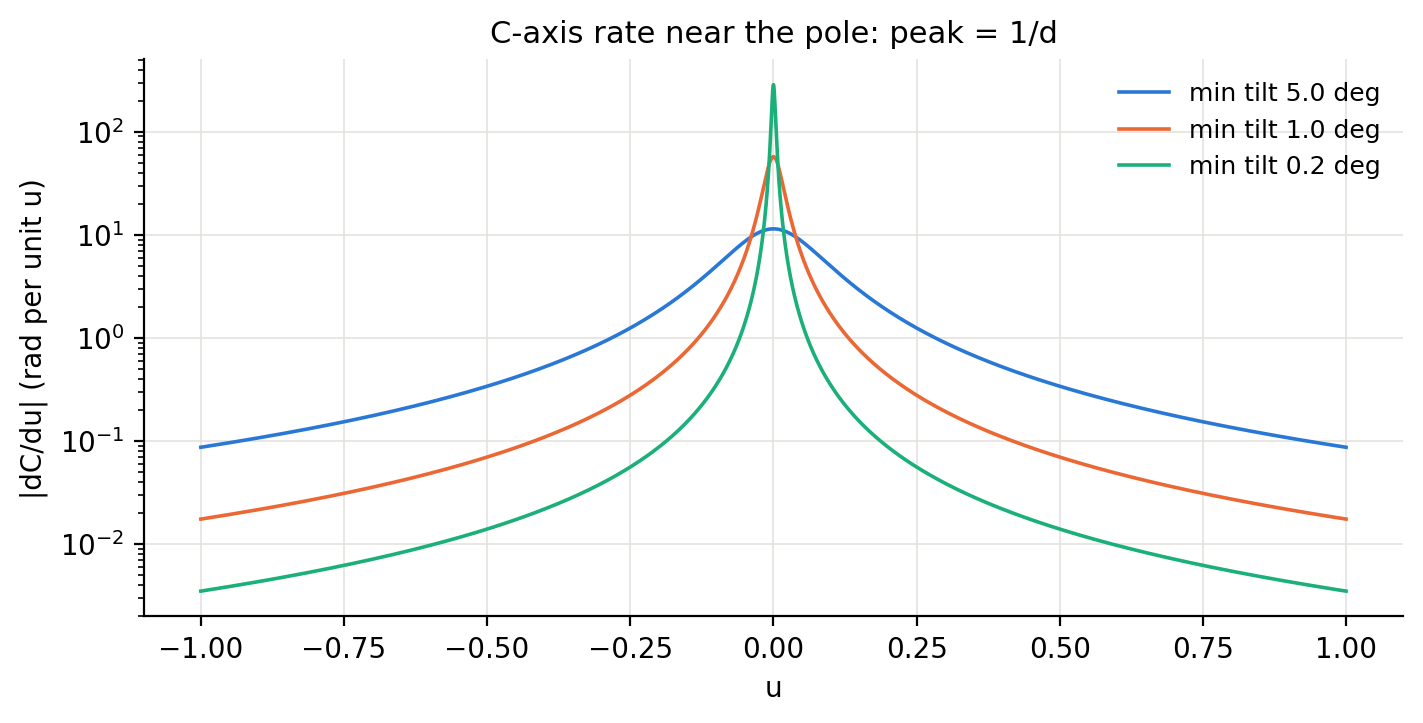

In [17]:
def pole_pass(d, n=20001):
    """刀轴 o(u) = unit([u, d, 1])，u ∈ [-1, 1]：在切平面上沿直线掠过极点，离极点 d。返回 u 与 o 的导数栈。"""
    u = np.linspace(-1.0, 1.0, n)
    r = np.zeros((4, n, 3))
    r[0] = np.column_stack([u, np.full(n, d), np.ones(n)])
    r[1, :, 0] = 1.0  # r' = [1, 0, 0]，更高阶为 0
    return u, cx.calculus.unit_derivatives(r)


fig, ax = plt.subplots(figsize=(7, 3.5))
for deg, color in zip((5.0, 1.0, 0.2), plotting.COLORS[:3]):
    d = np.tan(np.deg2rad(deg))
    u, o = pole_pass(d)
    c = cx.calculus.arg_derivatives(o[..., 1] + 1j * o[..., 0])  # AC 机床 w = o_y + i o_x
    reference = d / (d**2 + u**2)
    err = np.abs(c[1] - reference).max() / reference.max()
    omega = np.linalg.norm(o[1], axis=-1).max()
    print(f"最小倾角 {deg:>3}°：|C′| max = {np.abs(c[1]).max():6.1f}（1/d = {1 / d:6.1f}），", end="")
    print(f"相对误差 {err:.1e}，|o′| max = {omega:.3f}")
    assert err < 1e-12
    ax.plot(u, np.abs(c[1]), color=color, label=f"min tilt {deg} deg")
ax.set(xlabel="u", ylabel="|dC/du| (rad per unit u)", yscale="log", title="C-axis rate near the pole: peak = 1/d")
ax.legend()
plt.show()

三条直线上刀轴的角速度都不超过 1，$C$ 的峰值角速度却分别是 11、57、286，正好是 $1/d$；
与解析解的相对误差在 $10^{-16}$ 量级。每条直线走完，$C$ 都要转过接近 $180^\circ$，而且大部分集中在离极点最近的一小段里。
所以离极点 0.2° 的刀路，刀尖进给再慢，$C$ 轴也可能超速。

数值上还有一个隐患在倾角一侧：$A=\arccos o_z$ 的外函数导数是 $-1/\rho$，$\rho=\sqrt{1-o_z^2}$。
倾角很小时 $1-o_z^2\approx\rho^2$ 本身很小，而 $o_z^2$ 的舍入误差约 $10^{-16}$，两者相减会丢掉有效数字：
$\rho$ 越小丢得越多，$\rho\le10^{-8}$ 时 $1-o_z^2$ 直接被舍入成 0，除出来是 `inf`/`NaN`。
`calculus.acos_derivatives` 因此让调用者传入 $\rho=|w|=\sqrt{o_x^2+o_y^2}$，没有 $1-o_z^2$ 的相消。
同一族直线上的倾角 $A=\arctan\sqrt{u^2+d^2}$ 也有解析导数 $A'=u/\big(\sqrt{u^2+d^2}\,(1+u^2+d^2)\big)$，拿它对照两种写法：

In [18]:
print(f"{'d':>7s} {'naive rel err':>14s} {'|w| rel err':>12s} {'naive non-finite':>17s}")
for d in (1e-2, 1e-4, 1e-6, 1e-8, 1e-10):
    u, o = pole_pass(d)
    rho = np.abs(o[0, :, 1] + 1j * o[0, :, 0])
    with np.errstate(divide="ignore", invalid="ignore"):
        naive = cx.calculus.acos_derivatives(o[..., 2])  # 朴素：ρ = √(1 − o_z²)
        stable = cx.calculus.acos_derivatives(o[..., 2], rho=rho)
    q = u**2 + d**2
    reference = u / (np.sqrt(q) * (1 + q))
    near = np.abs(u) < 50 * d + 1e-3  # 只看离极点近的样本，远处两者都准
    err_naive = np.abs(naive[1] - reference)[near].max() / np.abs(reference[near]).max()
    err_stable = np.abs(stable[1] - reference)[near].max() / np.abs(reference[near]).max()
    print(f"{d:7.0e} {err_naive:14.1e} {err_stable:12.1e} {np.sum(~np.isfinite(naive[1])):17d}")
    assert err_stable < 1e-14

      d  naive rel err  |w| rel err  naive non-finite
  1e-02        7.5e-13      6.8e-16                 0
  1e-04        2.2e-09      3.3e-16                 0
  1e-06        6.4e-09      4.4e-16                 0
  1e-08            nan      4.4e-16                 1
  1e-10            nan      4.4e-16                 1


朴素写法的误差随 $d$ 减小一路变大，$d=10^{-8}$ 起出现 NaN（误差也就打印成 `nan`）；传入 $|w|$ 的写法始终在 $10^{-16}$ 量级。

**要点**：$w=0$ 是极点，$C$ 不定；刀轴离极点 $d$ 掠过时，$C$ 的角速度峰值约为刀轴角速度的 $1/d$ 倍。倾角导数用 $\rho=|w|$ 代替 $\sqrt{1-o_z^2}$，避开 $1-o_z^2$ 的相消。靠近极点的刀路要用 `metrics.axis_report`（第 6 节）检查各轴，或者改刀轴绕开（路线图第 4 节）。

## 5. 机床轴的解析导数

前瞻和插补要的不只是 $q$ 的值，还有 $q$ 对弧长（进而对时间）的 1~3 阶导数：$\dot q = q_s v$、$\ddot q = q_{ss}v^2 + q_s a$、$\dddot q = q_{sss}v^3 + 3q_{ss}va + q_s j$。`axis_motion` 全部解析给出，没有差分：

- 倾角 $=\arccos o_z$：外函数导数 $-1/\rho,\ -z/\rho^3,\ -(1+2z^2)/\rho^5$，链式法则复合；
- $C$ 角 $=\operatorname{Im}\log w$：外函数导数 $1/w,\ -1/w^2,\ 2/w^3$；
- $\mathbf{R}=\mathbf{R}_x(A)\mathbf{R}_z(C)$：$\mathrm{d}^k\mathbf{R}/\mathrm{d}\theta^k=\mathbf{K}^k\mathbf{R}$（$\mathbf{K}$ 为旋转轴生成元），两个旋转矩阵相乘、$\mathbf{R}\mathbf{p}$ 用 Leibniz 法则。

用五点中心差分（对解析逆解的 0 阶值取差分）当独立参考，逐阶核对：

In [19]:
N = 200
H = {1: 1e-4, 2: 1e-4, 3: 2e-3}  # 差分步长：k 阶五点参考的截断误差 ~ h⁴f⁽ᵏ⁺⁴⁾
path = cx.CurvePath(pose_plain, chord_error=1e-3)
s_center = np.linspace(0.73, path.length - 0.73, N)


def q_stencil(k):
    """每个中心样本左右各 2 个点（步距 H[k]）上的解析逆解，形状 (N, 5, 5)：样本、差分点、轴。"""
    s_cols = s_center[:, None] + np.arange(-2, 3) * H[k]
    d = path.derivatives(s_cols.ravel())[0]
    return machine.inverse_path(d[:, :3], d[:, 3:]).reshape(N, 5, 5)

In [20]:
def fd_reference(k):
    """五点中心差分：f0 … f4 是 s − 2h … s + 2h 处的 q。"""
    q5 = q_stencil(k)
    h = H[k]
    f0, f1, f2, f3, f4 = (q5[:, j] for j in range(5))
    if k == 1:
        return (f0 - 8 * f1 + 8 * f3 - f4) / (12 * h)
    if k == 2:
        return (-f0 + 16 * f1 - 30 * f2 + 16 * f3 - f4) / (12 * h**2)
    return (-f0 + 2 * f1 - 2 * f3 + f4) / (2 * h**3)

In [21]:
d_center = path.derivatives(s_center)
q_ana = machine.axis_motion(d_center[..., :3], d_center[..., 3:])
for k in (1, 2, 3):
    ref = fd_reference(k)[3:-3]
    err = np.abs(q_ana[k, 3:-3] - ref)
    rel = err.max(0) / np.abs(ref).max(0)
    rel_text = np.array2string(rel, formatter={"float_kind": "{:.1e}".format})
    print(f"{k} 阶：最大绝对误差 {err.max():.3e}，各轴相对误差 {rel_text}")
    bound = (1e-5, 1e-3, 5e-2)[k - 1]  # 参考自身的截断误差随阶数增大
    assert rel.max() < bound

1 阶：最大绝对误差 1.483e-07，各轴相对误差 [1.5e-07 1.2e-07 1.3e-07 1.5e-07 1.3e-07]
2 阶：最大绝对误差 1.665e-05，各轴相对误差 [8.4e-05 2.8e-04 5.8e-05 1.7e-04 1.2e-04]
3 阶：最大绝对误差 2.290e-04，各轴相对误差 [7.0e-03 4.3e-03 7.4e-03 6.5e-03 1.1e-02]


逐阶的相对误差（一阶 $1.5\times10^{-7}$、二阶 $3\times10^{-4}$、三阶 $10^{-3}$ 到 $10^{-2}$）与各阶差分参考自身的截断和舍入误差同量级。误差随阶数增大是差分的特点，不是解析导数的误差。这三阶导数就是下一节把刀尖限制"翻译"成各轴限制的原料。

**要点**：机床轴的 1~3 阶导数全部解析；$q$ 对弧长的导数经 $\dot s = v$ 的链式法则就得到对时间的导数。

## 6. 全流程：刀尖满足，各轴未必

把前几节拼起来走一遍完整流程（与 `examples/five_axis.py` 相同）：五轴样条 → `CurvePath`（曲率峰值处切 block）→ 前瞻 + 七段 S 曲线 → 插补时顺带给出机床轴 → 检查各轴。刀尖进给的限制取 $v_{\max}=50$ mm/s、$a_{\max}=500$ mm/s²、$j_{\max}=5000$ mm/s³；各轴上限（`DriveLimits`，旋转轴单位 rad/s 等）取：

In [22]:
from cnc5x import metrics

limits = cx.DriveLimits(
    velocity=[60, 60, 60, 1.0, 2.0],  # X Y Z (mm/s)，A C (rad/s)
    acceleration=[600, 600, 600, 5.0, 10.0],
    jerk=[6000, 6000, 6000, 50.0, 100.0],
)
profile, knots, v = cx.schedule(path, v_max=50, a_max=500, j_max=5000, Ts=TS)
commands = cx.interpolate(path, profile, TS, machine=machine)
print(f"刀尖弧长 {path.length:.1f} mm，{len(path.blocks)} 个 block，用时 {commands.t[-1]:.3f} s")
p_fwd, o_fwd = machine.forward(commands.q[0])
err_p = np.abs(p_fwd - commands.position).max()
err_o = np.abs(o_fwd - commands.orientation).max()
print(f"正解回代残差：位置 {err_p:.1e} mm，刀轴 {err_o:.1e}")

刀尖弧长 344.7 mm，11 个 block，用时 7.095 s
正解回代残差：位置 2.8e-14 mm，刀轴 2.2e-16


In [23]:
report = metrics.axis_report(commands.q, limits)
print("各轴超限比 = 峰值 / 上限：" + "".join(f"{n:>9s}" for n in machine.axis_names))
for quantity, label in (("velocity", "速度"), ("acceleration", "加速度"), ("jerk", "jerk")):
    print(f"  {label:5s}" + "".join(f"{r:9.3f}" for r in report[quantity]["ratio"]))

各轴超限比 = 峰值 / 上限：        X        Y        Z        A        C
  速度       0.828    0.140    0.365    0.320    0.842
  加速度      0.895    0.107    0.393    0.613    0.880
  jerk     0.740    0.216    0.638    0.582    2.154


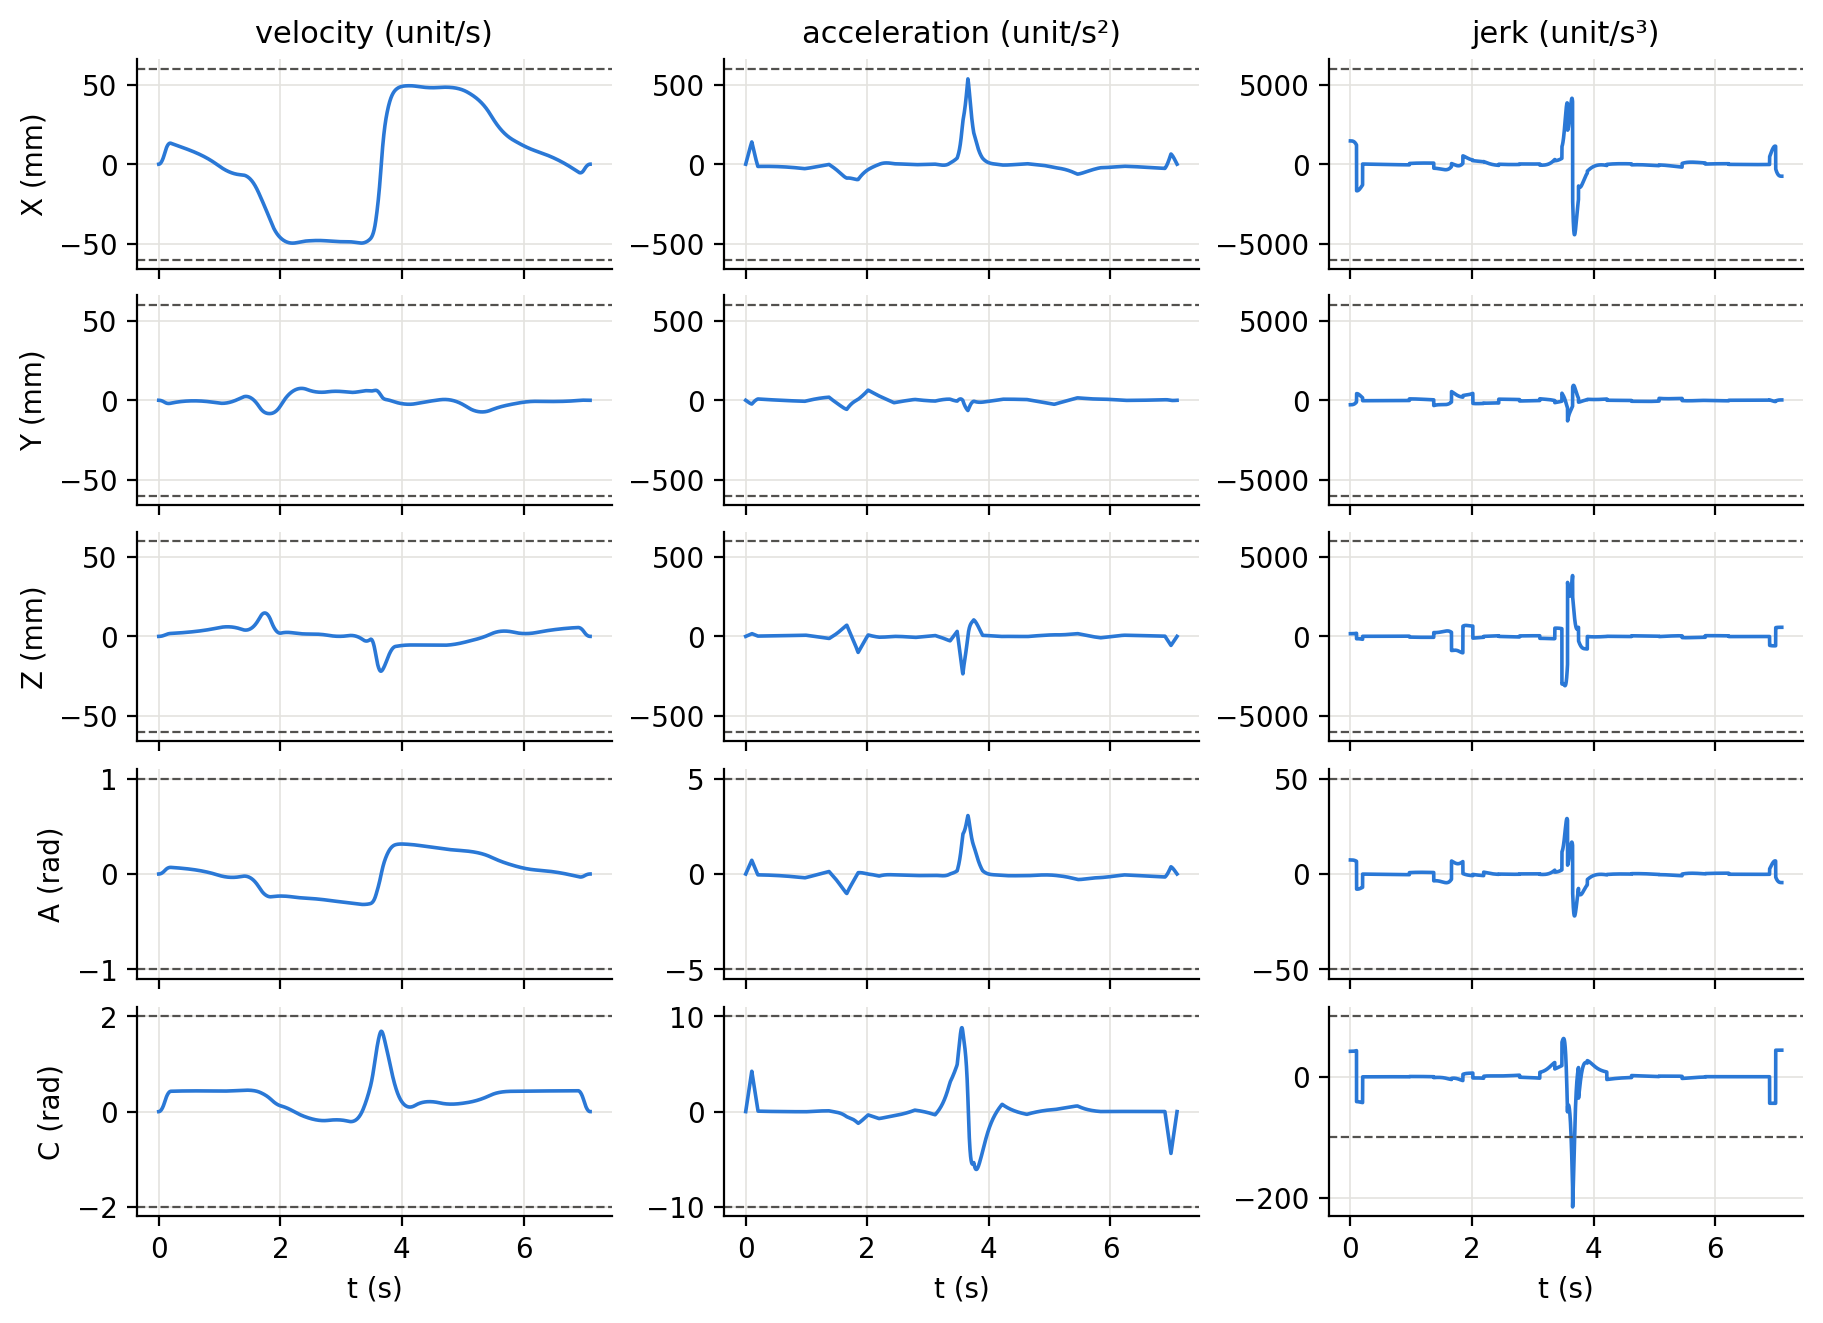

In [24]:
fig, axes = plotting.plot_axes(commands.t, commands.q, limits)
fig.set_size_inches(9, 6.5)
plt.show()

刀尖进给全程贴着规划走（$v\le50$），但 **C 轴 jerk 超限比约 2.2**（峰值 215 rad/s³，上限 100）。原因就在第 5 节的换元公式里：$\dddot q_C = q_{sss}v^3 + 3q_{ss}va + q_s j$，$j_{\max}=5000$ mm/s³ 乘上 $q_s$ 后可能远超旋转轴自己的 jerk 上限。平动轴与旋转轴的量纲不同（mm 与 rad），它们的上限互相独立，必须逐个轴检查。

**要点**：刀尖进给满足限制，各轴未必。五轴的最后一道关是 `metrics.axis_report` 按轴核对。

## 7. 超限怎么办

两种现成的办法：

**(a) 整体放慢**（`time_scale_factor` + `Profile.scaled`）：$t\to\lambda t$ 后 $\dot q,\ddot q,\dddot q$ 分别除以 $\lambda,\lambda^2,\lambda^3$，所以 $\lambda=\max(1, r_v, \sqrt{r_a}, \sqrt[3]{r_j})$，$r$ 为最大超限比。一行就够，但全程变慢。

**(b) 进给包络**（`feed_envelope` + `schedule(envelope=...)`）：沿弧长采样，给出匀速通过每一点时的进给上限

$$
v_{\mathrm{lim}}(s)=\min\!\Big(v_{\max},\; v_{\mathrm{chord}},\; \sqrt{A/\kappa},\; (J/\kappa^2)^{1/3},\; \min_{\text{各轴}}\big(\tfrac{V}{|q_s|},\ \sqrt{\tfrac{A}{|q_{ss}|}},\ \sqrt[3]{\tfrac{J}{|q_{sss}|}}\big)\Big),
$$

让 block 内部也不超过它（`schedule` 自动在超限处加连接点）。只在需要的地方减速。

In [25]:
factor = cx.time_scale_factor(commands.q, limits)
cmd_slow = cx.interpolate(path, profile.scaled(factor * 1.001), TS, machine=machine)
ratio_slow = max(np.max(val["ratio"]) for val in metrics.axis_report(cmd_slow.q, limits).values())
t0, t1 = commands.t[-1], cmd_slow.t[-1]
print(f"(a) 整体放慢 λ = {factor:.3f}：用时 {t0:.3f} → {t1:.3f} s，最大超限比 {ratio_slow:.3f}（样本上）")

(a) 整体放慢 λ = 1.291：用时 7.095 → 9.172 s，最大超限比 0.997（样本上）


In [26]:
s_env = np.linspace(0, path.length, 20000)
v_env = cx.feed_envelope(path, s_env, TS, 50, 500, 5000, chord_error=1e-3, machine=machine, drives=limits)
profile_env, knots_env, _ = cx.schedule(path, v_max=50, a_max=500, j_max=5000, Ts=TS, envelope=(s_env, v_env))
cmd_env = cx.interpolate(path, profile_env, TS, machine=machine)
jerk_ratio = metrics.axis_report(cmd_env.q, limits)["jerk"]["ratio"]
extra = len(knots_env) - len(knots)
print(f"(b) 进给包络：连接点 {len(knots_env)} 个（比不用包络多 {extra} 个），用时 {cmd_env.t[-1]:.3f} s")
print(f"    jerk 超限比 {np.round(jerk_ratio, 2)}")

(b) 进给包络：连接点 12 个（比不用包络多 0 个），用时 7.203 s
    jerk 超限比 [0.89 0.31 0.85 0.63 2.67]


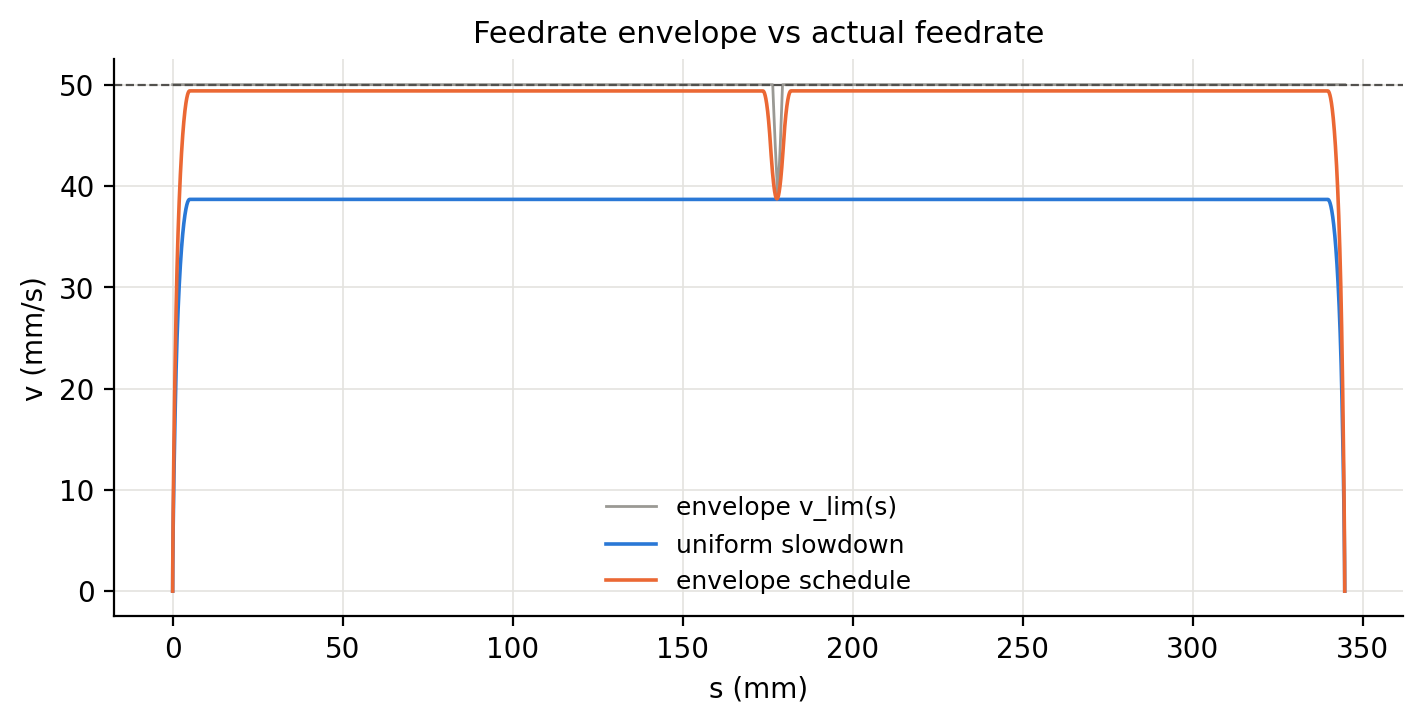

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(s_env, v_env, color=plotting.GRAY, lw=1.0, label="envelope v_lim(s)")
ax.plot(cmd_slow.feed[0], cmd_slow.feed[1], color=plotting.COLORS[0], label="uniform slowdown")
ax.plot(cmd_env.feed[0], cmd_env.feed[1], color=plotting.COLORS[1], label="envelope schedule")
ax.axhline(50, color=plotting.LIMIT, ls="--", lw=0.8)
ax.set_xlabel("s (mm)")
ax.set_ylabel("v (mm/s)")
ax.set_title("Feedrate envelope vs actual feedrate")
ax.legend()
plt.show()

包络版用时只多约 0.1 s（7.10 → 7.20 s），远好于整体放慢的 9.17 s。但 C 轴 jerk 超限比从 2.2 **升**到约 2.7——包络没有解决这个问题。拆开看为什么：包络只含**匀速项** $q_{sss}v^3$（匀速时 $a=j=0$），而切向加减速带来的 $3q_{ss}va$ 与 $q_s j$ 不在其中。把 C 轴 jerk 最大处的三项分解出来：

In [28]:
k = np.argmax(np.abs(cmd_env.q[3, :, 4]))
s_k, v_k, a_k, j_k = cmd_env.feed[:, k]
d_k = path.derivatives(s_k)
q_k = machine.axis_motion(d_k[:, None, :3], d_k[:, None, 3:])[:, 0, 4]
terms = q_k[3] * v_k**3, 3 * q_k[2] * v_k * a_k, q_k[1] * j_k
print(f"t = {cmd_env.t[k]:.3f} s 处（v = {v_k:.1f} mm/s，a = {a_k:.0f}，j = {j_k:.0f}）：")
print(f"  匀速项 q_sss·v³ = {terms[0]:6.0f} rad/s³")
print(f"  交叉项 3q_ss·va = {terms[1]:6.0f} rad/s³")
print(f"  切向 jerk 项 q_s·j = {terms[2]:6.0f} rad/s³（上限 100）")

t = 3.663 s 处（v = 44.1 mm/s，a = -226，j = -4818）：
  匀速项 q_sss·v³ =    -49 rad/s³
  交叉项 3q_ss·va =    -71 rad/s³
  切向 jerk 项 q_s·j =   -147 rad/s³（上限 100）


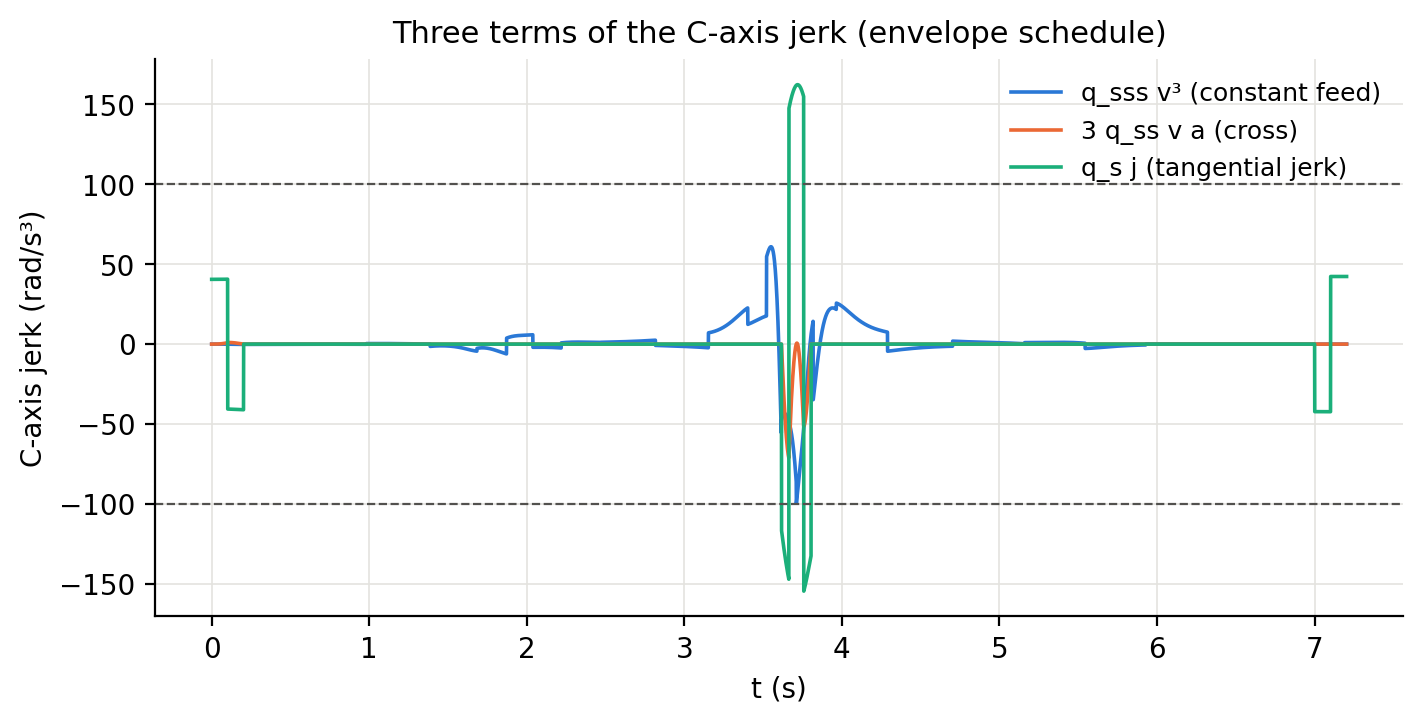

In [29]:
# 沿时间分解三项（一张图三个系列 + 上限虚线）
d_all = path.derivatives(np.clip(cmd_env.feed[0], 0, path.length))
q_s_all = machine.axis_motion(d_all[..., :3], d_all[..., 3:])[..., 4]  # C 轴对弧长的导数栈
v_all, a_all, j_all = cmd_env.feed[1], cmd_env.feed[2], cmd_env.feed[3]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(cmd_env.t, q_s_all[3] * v_all**3, color=plotting.COLORS[0], label="q_sss v³ (constant feed)")
ax.plot(cmd_env.t, 3 * q_s_all[2] * v_all * a_all, color=plotting.COLORS[1], label="3 q_ss v a (cross)")
ax.plot(cmd_env.t, q_s_all[1] * j_all, color=plotting.COLORS[2], label="q_s j (tangential jerk)")
ax.axhline(100, color=plotting.LIMIT, ls="--", lw=0.8)
ax.axhline(-100, color=plotting.LIMIT, ls="--", lw=0.8)
ax.set_xlabel("t (s)")
ax.set_ylabel("C-axis jerk (rad/s³)")
ax.set_title("Three terms of the C-axis jerk (envelope schedule)")
ax.legend()
plt.show()

In [30]:
factor_env = cx.time_scale_factor(cmd_env.q, limits)
print(f"若包络版再整体放慢：λ = {factor_env:.3f}，用时 {cmd_env.t[-1] * factor_env:.3f} s，反而比纯整体放慢更慢")

若包络版再整体放慢：λ = 1.388，用时 9.995 s，反而比纯整体放慢更慢


匀速项只有约 $-49$（包络管的就是它），切向 jerk 项 $-147$ 已经单独超限，交叉项 $-71$ 也不小。降低进给 $v$ 对 $q_s j$ 毫无作用——$j$ 是进给轮廓自己的 jerk。要治它得降低 $j_{\max}$（进给的 jerk），或者把切向项也计入包络（见 `docs/路线图.md` 第 2 节）。这与 `docs/数学约定.md` 第 3 节进给包络小节的说明一致。

**要点**：整体放慢一行见效但全程变慢；进给包络只在需要处减速，但只管匀速项。$q_s j$ 主导时降速无效，要降进给的 jerk。

## 8. 五轴拐角光顺

回到离散的 G01 世界：五轴 G01 段里刀尖走直线、刀轴沿大圆匀角速度转动，两者共用参数。拐角处刀尖方向与刀轴方向同时突变——`metrics.junction_jumps` 返回 $(n-1, 6)$：前三列是刀尖位置、单位切向、曲率向量的跳变，后三列是刀轴 $\hat{\mathbf{o}}, \hat{\mathbf{o}}_s, \hat{\mathbf{o}}_{ss}$ 的跳变（刀尖与刀轴分开列：毫米和弧度不能相加）。

`HermiteCornerPath` 在拐角两侧各裁去 $\ell$，用五次 Hermite 过渡（`hermite_transition`）：刀尖对弧长 $C^2$，刀轴先 Hermite 再单位化，对刀尖弧长同样 $C^2$。用 `impeller_blade_coarse`（52 点，叶片单道走刀，刀轴倾角 20°→90°）对比：

In [31]:
imp = cx.datasets.load_dataset("impeller_blade_coarse")
lin = cx.LinearPath(imp.points, imp.axes)
her = cx.HermiteCornerPath(imp.points, 0.05, 1e-3, axes=imp.axes)
jump_lin = metrics.junction_jumps(lin.curves)
jump_her = metrics.junction_jumps(her.curves)
print(f"拐角数 {lin.N - 1}，最大刀尖转角 {np.degrees(lin.turning_angles.max()):.1f}°")
print(f"G01     ：切向跳变 max {jump_lin[:, 1].max():.3f}，o_s 跳变 max {jump_lin[:, 4].max():.4f} rad/mm")
print(f"Hermite ：各列跳变 max {np.array2string(jump_her.max(0), precision=1)}")

拐角数 50，最大刀尖转角 101.9°
G01     ：切向跳变 max 1.553，o_s 跳变 max 0.0208 rad/mm
Hermite ：各列跳变 max [0.0e+00 9.8e-11 1.0e-12 2.7e-16 8.2e-13 2.7e-14]


In [32]:
# 相同进给限制下各走一遍，比较刀轴角速度 |ȯ|(t)
p_lin, _, _ = cx.schedule(lin, 120.0, 1500.0, 15000.0, TS)
c_lin = cx.interpolate(lin, p_lin, TS)
p_her, _, _ = cx.schedule(her, 120.0, 1500.0, 15000.0, TS)
c_her = cx.interpolate(her, p_her, TS)
omega_lin = metrics.tangential(c_lin.axis)[0]
omega_her = metrics.tangential(c_her.axis)[0]
print(f"G01：用时 {c_lin.t[-1]:.2f} s，|ȯ| max {np.nanmax(omega_lin):.2f} rad/s")
print(f"Hermite：用时 {c_her.t[-1]:.2f} s，|ȯ| max {np.nanmax(omega_her):.2f} rad/s")

G01：用时 5.77 s，|ȯ| max 1.65 rad/s
Hermite：用时 2.29 s，|ȯ| max 1.76 rad/s


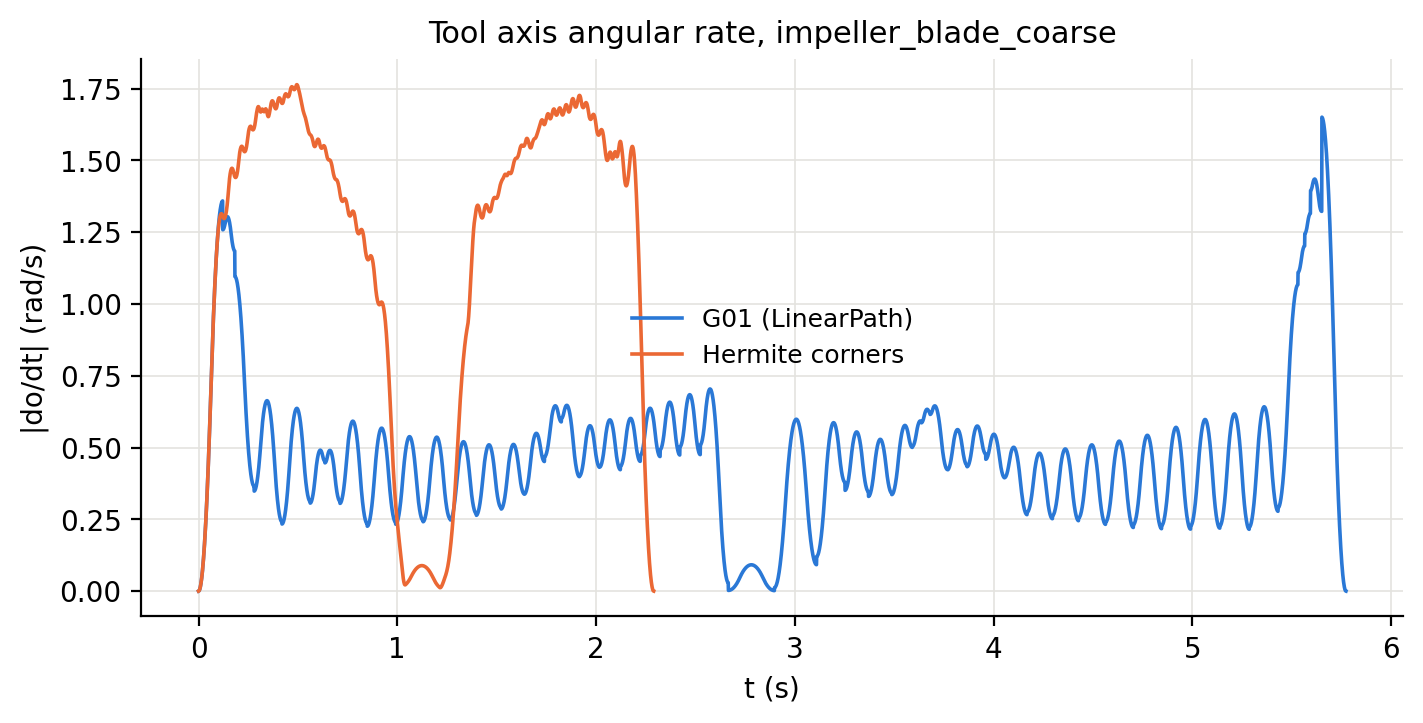

In [33]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(c_lin.t, omega_lin, color=plotting.COLORS[0], label="G01 (LinearPath)")
ax.plot(c_her.t, omega_her, color=plotting.COLORS[1], label="Hermite corners")
ax.set_xlabel("t (s)")
ax.set_ylabel("|do/dt| (rad/s)")
ax.set_title("Tool axis angular rate, impeller_blade_coarse")
ax.legend()
plt.show()

两条曲线的峰值差不多（数据本身相邻刀轴转角就不小），形状却很不一样。$|\dot{\hat{\mathbf{o}}}| = |\hat{\mathbf{o}}_s|\,v$：G01 的 $|\hat{\mathbf{o}}_s|$ 在段内是常数、拐角处跳变（对应 `junction_jumps` 里的 $o_s$ 跳变），进给 $v$ 又在每个拐角减速、出拐角再加速，所以蓝线随拐角一起一伏；Hermite 刀路的进给大部分时间在巡航，橙线主要反映刀轴沿弧长转得多快。真正的差别在进给上：G01 的拐角限速 $v \le a_{\max}T_s/(2\sin\beta)$（刀尖方向突变，一个周期内的速度矢量变化受限）让拐角处大幅降速，用时 5.8 s；光顺后按曲率限速，用时 2.3 s。刀轴侧的 $o_s$ 跳变消失后，旋转轴 jerk 里由它贡献的冲击也一并消失。

**要点**：五轴 G01 = 直线 + 大圆；五次 Hermite 过渡让刀尖 $C^2$、刀轴对刀尖弧长 $C^2$。注意 `HermiteCornerPath` 只限制了刀尖的逼近误差，刀轴偏差没有限制。

## 9. 练习

1. 把第 6 节的 `j_max` 从 5000 降到 1000 mm/s³，重新看 C 轴 jerk 超限比：验证"超限主要来自 $q_s j$"的论断；再试只把 C 轴 jerk 上限放宽到 300，两种超限各自需要多大的 $\lambda$。
2. 第 4 节取 `pole_pass(0.0)`（刀轴正好穿过极点），用 `machine.axis_motion` 看 $C$ 与各阶导数在 $u=0$ 处怎么处理（读 `kinematics.py` 的 docstring）；再用 `machine.inverse(..., branch=-1)` 看 $C$ 差 $\pi$。
3. 在第 2 节的 `line_end_snap_sweep90` 上画两种参数化的 $|\mathrm{d}\hat{\mathbf{o}}/\mathrm{d}s|$：同步版没有过冲，峰值角速度却更大，为什么？如果有两个相邻刀轴完全相同，`angle_parameters` 会遇到什么问题？
4. 第 8 节把 `tolerance` 从 0.05 加到 0.5，看 `HermiteCornerPath.trim` 什么时候被"相邻段长的一半"截断，用时和 $|\dot{\hat{\mathbf{o}}}|$ 怎么变。

## 延伸阅读

- `../docs/数学约定.md`：第 3 节进给包络小节（包络只含匀速项），第 6 节全部（$\rho=|w|$、极点、球坐标刀轴、参数同步、五轴 Hermite 过渡）。
- `../docs/路线图.md`：第 1 节纯转刀轴段（G01 里"刀尖不动只转刀轴"目前报错），第 2 节把切向项计入包络与 block 结构之外的调度器，第 4 节通用运动学链与 RTCP、奇异点避让。
- `../examples/five_axis.py`：本节全流程的脚本版。
- 论文：Yuen et al. 2013（刀轴角度参数化与同步、球坐标刀轴，库里对应 `angle_parameters`、`SphericalCurve`，尚未在 `../papers/` 单独复现）；Langeron et al. 2004（双样条刀路 `dual_spline`）。